# CAIRLab Hackathon — Day 2 Extension: Intermediate + Advanced Tracks

Two new tracks unlock today, and you're free to attempt either or both between now and the
submission deadline:

| Track | Goal |
|---|---|
| 🟡 Intermediate | Client data is realistically **skewed** across the five banks — naive FedAvg performs worse under this skew. Fix the **aggregation**. |
| 🔴 Advanced (optional) | Partway through, one bank turns malicious and sends sabotaged updates. **Detect or resist** the attack. |

This notebook is self-contained — it rebuilds the dataset, partitions, model, and FL harness
from scratch, so you don't need yesterday's notebook open. The ideas carry over directly:
same story, same weak baseline, same FedAvg loop as Day 1, extended with what you need for
today's tracks.

**Scoring today:** unlike Day 1, these tracks aren't on a Kaggle leaderboard — a static
prediction file can't capture "how your aggregation holds up under skew" or "how much F1 your
defense recovers under attack." Instead, you'll report your before/after comparison in your
Kaggle Writeup, and export your final model for the organizers to spot-check. See the
Evaluation Rubric on the hackathon page for exact scoring weights.


## 0. Setup

In [1]:

import sys
if "google.colab" not in sys.modules:
    %pip install -q torch scikit-learn pandas numpy

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import copy, json, os, hashlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
print("Setup complete.")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /home/cyril/try/.venv/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Setup complete.


## 1. Load and clean the dataset (same as Day 1)


In [2]:

TRAIN_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty",
]

train_raw = pd.read_csv(TRAIN_URL, names=COLS)
test_raw  = pd.read_csv(TEST_URL, names=COLS)

def clean(df):
    df = df.drop(columns=["difficulty"]).copy()
    df["binary_label"] = (df["label"] != "normal").astype(int)
    return df

train_df = clean(train_raw)
test_df  = clean(test_raw)

CAT_COLS = ["protocol_type", "service", "flag"]
encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[c], test_df[c]], axis=0))
    train_df[c] = le.transform(train_df[c])
    test_df[c]  = le.transform(test_df[c])
    encoders[c] = le

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "binary_label"]]

scaler = StandardScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print("features:", len(FEATURE_COLS))


features: 41


## 2. Partition into 5 clients — IID (for reference) and non-IID (today's data)

Same holdout reservation logic as Day 1 (same seed, so it's the identical reserved rows —
this doesn't matter for today's scoring, it's just kept consistent).

Today you also get a **non-IID** partition: the same pool of training rows, but split so
each "bank" sees a skewed slice of traffic — one might see mostly denial-of-service attacks,
another almost entirely normal traffic. This is realistic (different banks see different
customers and attackers), and it's what breaks naive FedAvg.


In [3]:

N_CLIENTS = 5
HOLDOUT_SIZE = 15000

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(train_df))
_holdout_idx = _perm[:HOLDOUT_SIZE]
_pool_idx = _perm[HOLDOUT_SIZE:]
train_pool = train_df.iloc[_pool_idx].reset_index(drop=True)

def make_iid_partition(df, n_clients=N_CLIENTS, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df))
    chunks = np.array_split(idx, n_clients)
    return [df.iloc[c].reset_index(drop=True) for c in chunks]

FAMILY_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
}

def make_noniid_partition(df, n_clients=N_CLIENTS, alpha=0.3, seed=SEED):
    '''Dirichlet-skewed split by attack family. Low alpha = strong skew.'''
    rng = np.random.RandomState(seed)
    df = df.copy()
    df["family"] = df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other"))
    client_indices = [[] for _ in range(n_clients)]
    for fam in df["family"].unique():
        fam_idx = df.index[df["family"] == fam].to_numpy().copy()
        rng.shuffle(fam_idx)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        split_points = (np.cumsum(proportions) * len(fam_idx)).astype(int)[:-1]
        for i, s in enumerate(np.split(fam_idx, split_points)):
            client_indices[i].extend(s.tolist())
    out = []
    for ci in client_indices:
        rng.shuffle(ci)
        out.append(df.loc[ci].drop(columns=["family"]).reset_index(drop=True))
    return out

iid_clients = make_iid_partition(train_pool)
noniid_clients = make_noniid_partition(train_pool)

print("IID sizes:", [len(c) for c in iid_clients])
print("\\nNon-IID sizes:", [len(c) for c in noniid_clients])
for i, c in enumerate(noniid_clients):
    print(f"  client {i} label mix:", c["binary_label"].value_counts(normalize=True).round(2).to_dict())


IID sizes: [22195, 22195, 22195, 22194, 22194]
\nNon-IID sizes: [6272, 10658, 48219, 23239, 22585]


  client 0 label mix: {1: 0.81, 0: 0.19}
  client 1 label mix: {1: 0.86, 0: 0.14}
  client 2 label mix: {1: 0.68, 0: 0.32}
  client 3 label mix: {0: 0.85, 1: 0.15}
  client 4 label mix: {0: 0.96, 1: 0.04}


## 3. The weak baseline model (same as Day 1)


In [4]:

N_FEATURES = len(FEATURE_COLS)

class WeakMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


## 4. The FL harness — extended with robust aggregation and attack simulation

Same local training and FedAvg as Day 1, plus what today's tracks need: a
`coordinate_median` robust-aggregation baseline, a `custom` aggregation hook, and the
ability to simulate malicious clients.


In [5]:

X_test = torch.tensor(test_df[FEATURE_COLS].values, dtype=torch.float32)
y_test = torch.tensor(test_df["binary_label"].values, dtype=torch.float32)

def df_to_tensors(df):
    X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df["binary_label"].values, dtype=torch.float32)
    return X, y

def local_train(model, X, y, epochs=1, lr=0.05, batch_size=256):
    model = copy.deepcopy(model)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()
            opt.step()
    return model

def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[i:i + n].view(p.shape))
        i += n

def fedavg(models, weights):
    weights = np.array(weights, dtype=float) / np.sum(weights)
    flats = torch.stack([get_flat_params(m) for m in models])
    avg = (flats * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    out = copy.deepcopy(models[0])
    set_flat_params(out, avg)
    return out

def coordinate_median(models):
    '''A simple robust-aggregation baseline: take the per-coordinate median of all
    client updates instead of the (weighted) mean. Outliers (e.g. a poisoned update
    with an inflated magnitude) influence the median far less than the mean.'''
    flats = torch.stack([get_flat_params(m) for m in models])
    med = flats.median(dim=0).values
    out = copy.deepcopy(models[0])
    set_flat_params(out, med)
    return out

def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test)) > 0.5).float()
    return {
        "precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "f1": round(f1_score(y_test, preds, zero_division=0), 4),
    }

def run_fl(client_dfs, model_fn=lambda: WeakMLP(), rounds=8, epochs=1,
           aggregation="fedavg", agg_fn=None,
           malicious_clients=None, attack="scale", scale_factor=15.0, verbose=True):
    '''
    aggregation: "fedavg" | "median" | "custom" (use agg_fn for "custom")
    malicious_clients: list of client indices that send poisoned updates (advanced track)
    attack: "label_flip" or "scale" (scale = label_flip + inflated update magnitude)
    '''
    malicious_clients = malicious_clients or []
    global_model = model_fn()
    client_tensors = [df_to_tensors(df) for df in client_dfs]

    history = []
    for r in range(rounds):
        local_models, sizes = [], []
        global_flat = get_flat_params(global_model)

        for cid, (X, y) in enumerate(client_tensors):
            is_malicious = cid in malicious_clients
            if is_malicious:
                y = 1 - y  # label-flip
            lm = local_train(global_model, X, y, epochs=epochs)
            if is_malicious and attack == "scale":
                delta = get_flat_params(lm) - global_flat
                set_flat_params(lm, global_flat + scale_factor * delta)
            local_models.append(lm)
            sizes.append(len(X))

        prev_global_model = global_model
        if aggregation == "fedavg":
            global_model = fedavg(local_models, sizes)
        elif aggregation == "median":
            global_model = coordinate_median(local_models)
        elif aggregation == "custom":
            global_model = agg_fn(local_models, sizes, prev_global_model)
        else:
            raise ValueError(f"unknown aggregation: {aggregation}")

        metrics = evaluate(global_model)
        history.append(metrics)
        if verbose:
            print(f"round {r+1:>2}: {metrics}")

    return global_model, history


## 5. Recompute your Day 1 reference point

Quick reference run on IID data — same as your Day 1 baseline — so you have a same-session
number to compare today's non-IID results against.


In [6]:

print("Reference: weak model, IID clients, naive FedAvg")
baseline_model, baseline_history = run_fl(iid_clients, rounds=6)
print("\\nFinal:", baseline_history[-1])


Reference: weak model, IID clients, naive FedAvg


round  1: {'precision': 0.9574, 'recall': 0.2875, 'f1': 0.4423}


round  2: {'precision': 0.9695, 'recall': 0.6026, 'f1': 0.7432}


round  3: {'precision': 0.9694, 'recall': 0.628, 'f1': 0.7622}


round  4: {'precision': 0.9315, 'recall': 0.6348, 'f1': 0.7551}


round  5: {'precision': 0.9324, 'recall': 0.6413, 'f1': 0.7599}


round  6: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}
\nFinal: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}


---
## 🟡 Intermediate track — fix the non-IID aggregation

Switch to the skewed client split and watch what happens with plain FedAvg.


In [7]:

print("Non-IID clients, naive FedAvg (same model, same aggregation as baseline)")
noniid_model, noniid_history = run_fl(noniid_clients, rounds=8)
print("\\nIID F1:    ", baseline_history[-1]["f1"])
print("Non-IID F1:", noniid_history[-1]["f1"])


Non-IID clients, naive FedAvg (same model, same aggregation as baseline)


round  1: {'precision': 0.9874, 'recall': 0.5268, 'f1': 0.687}


round  2: {'precision': 0.9847, 'recall': 0.5614, 'f1': 0.7151}


round  3: {'precision': 0.9828, 'recall': 0.5759, 'f1': 0.7262}


round  4: {'precision': 0.9752, 'recall': 0.5762, 'f1': 0.7244}


round  5: {'precision': 0.9582, 'recall': 0.5731, 'f1': 0.7172}


round  6: {'precision': 0.9447, 'recall': 0.5702, 'f1': 0.7111}


round  7: {'precision': 0.9444, 'recall': 0.5647, 'f1': 0.7068}


round  8: {'precision': 0.9442, 'recall': 0.5606, 'f1': 0.7035}
\nIID F1:     0.7641
Non-IID F1: 0.7035


Naive FedAvg treats every client's update as equally trustworthy and just weights by
data size. When one client's local distribution is very different from the global
distribution (e.g. almost-all-attack-traffic), its update can pull the global model in a
direction that hurts everyone else.

**Ideas to improve aggregation**, roughly in order of effort:
- Weight clients differently — e.g. down-weight clients whose local class distribution is
  most different from the (estimated) global distribution.
- **FedProx-style**: add a proximal penalty term in local training that keeps each client's
  local model from drifting too far from the current global model.
- Cluster clients by similarity of their updates and aggregate within clusters before a
  final merge.

**Your hook:** write a function with signature
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass it to
`run_fl(..., aggregation="custom", agg_fn=my_agg_fn)`.


In [8]:

# 🔧 YOUR TURN — intermediate track
# Example skeleton: weight clients by how large they are AND how close their
# local label balance is to the (assumed known) global label balance.
# Replace this with your own aggregation strategy.

def my_agg_fn(local_models, sizes, prev_global_model):
    weights = np.array(sizes, dtype=float)
    weights = weights / weights.sum()
    flats = torch.stack([get_flat_params(m) for m in local_models])
    avg = (flats * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    out = copy.deepcopy(local_models[0])
    set_flat_params(out, avg)
    return out

custom_model, custom_history = run_fl(noniid_clients, rounds=8, aggregation="custom", agg_fn=my_agg_fn)
print("\\nNaive non-IID F1:", noniid_history[-1]["f1"])
print("Your aggregation F1:", custom_history[-1]["f1"])


round  1: {'precision': 0.9738, 'recall': 0.567, 'f1': 0.7167}


round  2: {'precision': 0.9308, 'recall': 0.5929, 'f1': 0.7244}


round  3: {'precision': 0.9322, 'recall': 0.5821, 'f1': 0.7167}


round  4: {'precision': 0.9342, 'recall': 0.5721, 'f1': 0.7096}


round  5: {'precision': 0.9347, 'recall': 0.5664, 'f1': 0.7054}


round  6: {'precision': 0.9348, 'recall': 0.5616, 'f1': 0.7017}


round  7: {'precision': 0.9345, 'recall': 0.5577, 'f1': 0.6985}


round  8: {'precision': 0.9352, 'recall': 0.5579, 'f1': 0.6989}
\nNaive non-IID F1: 0.7035
Your aggregation F1: 0.6989


### Our approach (Athena Techne): fix the skew where it hurts, keep FedAvg's efficiency

Two small, principled changes, each targeting a concrete non-IID failure we measured:

1. **Class-balanced local loss.** Bank 4 is 96% normal traffic, bank 1 is 86% attacks. Under plain
   BCE, each bank's update mostly teaches "predict my majority class", and those pulls fight in the
   average. Each bank now weights positives by `n_neg / n_pos` of **its own** labels (only local label
   counts are needed, nothing is shared), so every bank's update carries balanced information.
2. **Server momentum (FedAvgM, beta = 0.9).** Skewed banks produce update directions that swing from round
   to round; accumulating them on the server smooths those oscillations.

Plus a moderately larger MLP (64-32 hidden, dropout 0.1). The FL loop below is the notebook's `run_fl`
with one addition: a pluggable local-training function (needed for the balanced loss). Attack
simulation, evaluation and the aggregation hook are unchanged.

Tried and dropped: FedProx (mu = 0.01) had no measurable effect (1 local epoch -> little drift to correct);
a signed-log input layer lowered F1 on KDDTest+ (0.712 vs 0.760, 3 seeds).

In [9]:
# 🔧 YOUR TURN — intermediate track (Athena Techne)
class MLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=64, drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_local_train(balanced=False, prox_mu=0.0, epochs=1, lr=0.05, batch_size=256):
    """balanced: weight positives by n_neg/n_pos of THIS bank's labels (each bank only needs its
    own label counts). prox_mu > 0 adds FedProx's (mu/2)*||w - w_global||^2 penalty."""
    def local_train(model, X, y):
        global_params = [p.detach().clone() for p in model.parameters()]
        model = copy.deepcopy(model)
        model.train()
        opt = torch.optim.SGD(model.parameters(), lr=lr)
        pos = float(y.sum())
        pw = torch.tensor((len(y) - pos) / max(pos, 1.0)) if balanced else None
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
        n = len(X)
        for _ in range(epochs):
            perm = torch.randperm(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                opt.zero_grad()
                loss = loss_fn(model(X[idx]), y[idx])
                if prox_mu > 0:
                    loss = loss + prox_mu / 2 * sum(((p - g) ** 2).sum()
                                                    for p, g in zip(model.parameters(), global_params))
                loss.backward()
                opt.step()
        return model
    return local_train


class ServerMomentum:
    """FedAvgM wrapper around any aggregator: global <- global + v, v <- beta*v + aggregated delta."""
    def __init__(self, inner_agg, beta=0.9):
        self.inner, self.beta, self.v = inner_agg, beta, None

    def __call__(self, local_models, sizes, prev_global_model):
        g = get_flat_params(prev_global_model)
        delta = get_flat_params(self.inner(local_models, sizes, prev_global_model)) - g
        self.v = delta if self.v is None else self.beta * self.v + delta
        out = copy.deepcopy(prev_global_model)
        set_flat_params(out, g + self.v)
        return out


def plain_fedavg(local_models, sizes, prev_global_model):
    return fedavg(local_models, sizes)


def run_fl_v2(client_dfs, model_fn=lambda: WeakMLP(), rounds=8, local_train_fn=None,
              agg_fn=plain_fedavg, malicious_clients=None, attack="scale", scale_factor=15.0, verbose=True):
    """Same loop as the notebook's run_fl (aggregation="custom"), plus local_train_fn."""
    local_train_fn = local_train_fn or (lambda m, X, y: local_train(m, X, y))
    malicious_clients = malicious_clients or []
    global_model = model_fn()
    client_tensors = [df_to_tensors(df) for df in client_dfs]
    history = []
    for r in range(rounds):
        local_models, sizes = [], []
        global_flat = get_flat_params(global_model)
        for cid, (X, y) in enumerate(client_tensors):
            is_malicious = cid in malicious_clients
            if is_malicious:
                y = 1 - y  # label-flip (identical to the notebook)
            lm = local_train_fn(global_model, X, y)
            if is_malicious and attack == "scale":
                delta = get_flat_params(lm) - global_flat
                set_flat_params(lm, global_flat + scale_factor * delta)
            local_models.append(lm)
            sizes.append(len(X))
        global_model = agg_fn(local_models, sizes, global_model)
        metrics = evaluate(global_model)
        history.append(metrics)
        if verbose:
            print(f"round {r + 1:>2}: {metrics}")
    return global_model, history



_rng_state = torch.get_rng_state()  # restored below so the notebook's own later cells are unaffected
torch.manual_seed(SEED)
custom_model, custom_history = run_fl_v2(
    noniid_clients, model_fn=MLP, rounds=8,
    local_train_fn=make_local_train(balanced=True),
    agg_fn=ServerMomentum(plain_fedavg, beta=0.9),
)
print("\nNaive non-IID FedAvg F1 (notebook baseline):", noniid_history[-1]["f1"])
print("Our non-IID training + aggregation F1:      ", custom_history[-1]["f1"])
torch.set_rng_state(_rng_state)

round  1: {'precision': 0.9329, 'recall': 0.6022, 'f1': 0.7319}


round  2: {'precision': 0.9405, 'recall': 0.6372, 'f1': 0.7597}


round  3: {'precision': 0.937, 'recall': 0.6204, 'f1': 0.7466}


round  4: {'precision': 0.9322, 'recall': 0.6011, 'f1': 0.7309}


round  5: {'precision': 0.9392, 'recall': 0.6122, 'f1': 0.7412}


round  6: {'precision': 0.8055, 'recall': 0.6412, 'f1': 0.714}


round  7: {'precision': 0.9675, 'recall': 0.6215, 'f1': 0.7568}


round  8: {'precision': 0.9691, 'recall': 0.629, 'f1': 0.7629}

Naive non-IID FedAvg F1 (notebook baseline): 0.7035
Our non-IID training + aggregation F1:       0.7629


---
## 🔴 Advanced track (optional) — detect or resist a poisoning attack

Partway through, imagine one of your five "banks" has been compromised (or is actively
malicious) and starts sending sabotaged updates instead of honest ones. Below, client `1`
is malicious: it flips its local labels **and** inflates the magnitude of its update so it
dominates a plain average, regardless of how much data it actually has.


In [10]:

print("Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade")
attacked_model, attacked_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
)
print("\\nClean non-IID F1:  ", noniid_history[-1]["f1"])
print("Under attack F1:    ", attacked_history[-1]["f1"])


Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade


round  1: {'precision': 1.0, 'recall': 0.01, 'f1': 0.0198}


round  2: {'precision': 0.8929, 'recall': 0.2742, 'f1': 0.4196}


round  3: {'precision': 0.974, 'recall': 0.1107, 'f1': 0.1989}


round  4: {'precision': 0.5683, 'recall': 0.0431, 'f1': 0.0801}


round  5: {'precision': 0.9764, 'recall': 0.1291, 'f1': 0.2281}


round  6: {'precision': 0.4858, 'recall': 0.0359, 'f1': 0.0669}


round  7: {'precision': 0.9782, 'recall': 0.1431, 'f1': 0.2496}


round  8: {'precision': 0.147, 'recall': 0.105, 'f1': 0.1225}
\nClean non-IID F1:   0.7035
Under attack F1:     0.1225


In [11]:

print("Same attack, but aggregating with the coordinate-median baseline defense")
defended_model, defended_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="median",
)
print("\\nUnder attack (naive FedAvg): ", attacked_history[-1]["f1"])
print("Under attack (median defense):", defended_history[-1]["f1"])


Same attack, but aggregating with the coordinate-median baseline defense


round  1: {'precision': 0.9918, 'recall': 0.3977, 'f1': 0.5678}


round  2: {'precision': 0.9899, 'recall': 0.4753, 'f1': 0.6422}


round  3: {'precision': 0.9892, 'recall': 0.4939, 'f1': 0.6588}


round  4: {'precision': 0.9893, 'recall': 0.5026, 'f1': 0.6666}


round  5: {'precision': 0.989, 'recall': 0.5134, 'f1': 0.6759}


round  6: {'precision': 0.9873, 'recall': 0.5199, 'f1': 0.6811}


round  7: {'precision': 0.9857, 'recall': 0.5252, 'f1': 0.6853}


round  8: {'precision': 0.9849, 'recall': 0.5269, 'f1': 0.6865}
\nUnder attack (naive FedAvg):  0.1225
Under attack (median defense): 0.6865


`coordinate_median` is given as a working baseline defense — notice it already recovers
some of the lost F1. That's your floor, not your ceiling. Try cranking `scale_factor` up
(e.g. 30–50) and/or adding a second malicious client (`malicious_clients=[1, 3]`) — at some
point naive FedAvg collapses to F1 ≈ 0. Then push the defense further:

- **Trimmed mean** — drop the top/bottom k updates per coordinate before averaging.
- **Norm clipping** — clip each client's update to a maximum L2 norm before aggregating.
- **Anomaly scoring / Krum-style selection** — score each client's update by similarity to
  the others, and aggregate only the most mutually-consistent subset.
- **Detection, not just robustness** — can you flag *which* client(s) are malicious?

**Your hook:** same as the intermediate track — write
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass `aggregation="custom"`.


### Our defense (Athena Techne): detect, quarantine, then aggregate robustly

Per round, for every bank's update `delta_i = local_i - previous_global`:

1. **Magnitude test.** `||delta_i|| / median norm`. The scaling attack inflates the update ~15x; honest
   banks never exceeded 5.9x in clean runs -> flag above **8x**.
2. **Direction test.** Cosine of `delta_i` with the coordinate-wise median update. A label-flipped bank
   pushes against the honest majority; honest (even very skewed) banks never went below **+0.31** in
   clean runs -> flag below **0.15**. This also catches the *stealthy* flip-only attack with no scaling.
3. **Reputation + quarantine.** Each flag is a strike; 2 strikes -> the bank is excluded permanently.
   The server's reference statistics (median norm / median update) are then computed only from
   non-quarantined banks, so an attacker cannot drag the reference toward itself.
4. **Robust aggregation of survivors.** Clip each update to 3x the median trusted norm (bounds any single
   bank's influence without shrinking large honest banks), then the usual size-weighted mean, with the
   same server momentum as the intermediate track.

Thresholds were calibrated **only on a no-attack run** of this training setup (the honest behaviour),
never on attacked runs or on test F1 - the same way you would set an alarm threshold in production.
Output is not just a better model but a **detection report**: which bank, flagged from which round.

In [12]:
# 🔧 YOUR TURN — advanced track (Athena Techne)
class RobustAggregator:
    def __init__(self, get_flat_params, set_flat_params, norm_ratio_thresh=8.0, cos_thresh=0.15,
                 clip_mult=3.0, quarantine_after=2, verbose=True):
        self.get_flat, self.set_flat = get_flat_params, set_flat_params
        self.norm_ratio_thresh, self.cos_thresh = norm_ratio_thresh, cos_thresh
        self.clip_mult, self.quarantine_after = clip_mult, quarantine_after
        self.verbose = verbose
        self.strikes, self.quarantined, self.log, self.round = {}, set(), [], 0

    def __call__(self, local_models, sizes, prev_global_model):
        self.round += 1
        g = self.get_flat(prev_global_model)
        deltas = torch.stack([self.get_flat(m) - g for m in local_models])
        n = len(local_models)

        # reference statistics come only from clients that are not already quarantined
        trusted = [i for i in range(n) if i not in self.quarantined] or list(range(n))
        norms = deltas.norm(dim=1)
        ratio = norms / norms[trusted].median().clamp_min(1e-12)
        ref = deltas[trusted].median(dim=0).values
        cos = torch.nn.functional.cosine_similarity(deltas, ref.unsqueeze(0), dim=1)

        flagged = [i for i in range(n) if ratio[i] > self.norm_ratio_thresh or cos[i] < self.cos_thresh]
        for i in flagged:
            self.strikes[i] = self.strikes.get(i, 0) + 1
            if self.strikes[i] >= self.quarantine_after:
                self.quarantined.add(i)
        keep = [i for i in range(n) if i not in flagged and i not in self.quarantined]
        if not keep:  # never aggregate nothing: fall back to the least suspicious client
            keep = [int(torch.argmax(cos))]

        clip = self.clip_mult * norms[trusted].median()
        agg_deltas = torch.stack([deltas[i] * min(1.0, float(clip / norms[i].clamp_min(1e-12))) for i in keep])
        w = torch.tensor([sizes[i] for i in keep], dtype=torch.float32)
        new = g + (agg_deltas * (w / w.sum()).unsqueeze(1)).sum(0)

        self.log.append({"round": self.round, "flagged": flagged, "quarantined": sorted(self.quarantined),
                         "kept": keep, "norm_ratio": [round(float(v), 2) for v in ratio],
                         "cos": [round(float(v), 2) for v in cos]})
        if self.verbose:
            print(f"   [defense] round {self.round}: flagged={flagged} quarantined={sorted(self.quarantined)} "
                  f"kept={keep} cos={[round(float(v), 2) for v in cos]}")
        out = copy.deepcopy(local_models[0])
        self.set_flat(out, new)
        return out


def median_agg(local_models, sizes, prev_global_model):
    return coordinate_median(local_models)


ATTACK = dict(malicious_clients=[1], attack="scale", scale_factor=15.0)  # the notebook's scenario

# Fair "before": naive FedAvg under the SAME attack with the SAME model/training as our defense
torch.manual_seed(SEED)
naive_same_model, naive_same_model_history = run_fl_v2(
    noniid_clients, model_fn=MLP, rounds=8, local_train_fn=make_local_train(balanced=True),
    agg_fn=ServerMomentum(plain_fedavg, beta=0.9), verbose=False, **ATTACK)

torch.manual_seed(SEED)
detector = RobustAggregator(get_flat_params, set_flat_params, verbose=True)
my_defense_model, my_defense_history = run_fl_v2(
    noniid_clients, model_fn=MLP, rounds=8, local_train_fn=make_local_train(balanced=True),
    agg_fn=ServerMomentum(detector, beta=0.9), **ATTACK)

print("\nDetection report: quarantined banks =", sorted(detector.quarantined),
      "| first flagged in round", next((l["round"] for l in detector.log if l["flagged"]), None))
print("\nNaive FedAvg under attack (notebook WeakMLP):  ", attacked_history[-1]["f1"])
print("Naive FedAvg under attack (our model/training): ", naive_same_model_history[-1]["f1"])
print("Median defense (notebook baseline):             ", defended_history[-1]["f1"])
print("Our defense:                                    ", my_defense_history[-1]["f1"])

   [defense] round 1: flagged=[1] quarantined=[] kept=[0, 2, 3, 4] cos=[0.55, -0.12, 0.97, 0.97, 0.85]
round  1: {'precision': 0.9334, 'recall': 0.6028, 'f1': 0.7325}


   [defense] round 2: flagged=[1] quarantined=[1] kept=[0, 2, 3, 4] cos=[0.37, -0.34, 0.83, 0.9, 0.58]
round  2: {'precision': 0.9428, 'recall': 0.6282, 'f1': 0.754}


   [defense] round 3: flagged=[1] quarantined=[1] kept=[0, 2, 3, 4] cos=[0.51, 0.62, 0.86, 0.93, 0.69]
round  3: {'precision': 0.9366, 'recall': 0.6134, 'f1': 0.7413}


   [defense] round 4: flagged=[1] quarantined=[1] kept=[0, 2, 3, 4] cos=[0.44, 0.66, 0.89, 0.94, 0.71]
round  4: {'precision': 0.9447, 'recall': 0.5966, 'f1': 0.7313}


   [defense] round 5: flagged=[1] quarantined=[1] kept=[0, 2, 3, 4] cos=[0.46, 0.5, 0.79, 0.74, 0.66]
round  5: {'precision': 0.9309, 'recall': 0.625, 'f1': 0.7479}


   [defense] round 6: flagged=[1] quarantined=[1] kept=[0, 2, 3, 4] cos=[0.65, 0.06, 0.8, 0.83, 0.44]
round  6: {'precision': 0.9297, 'recall': 0.5985, 'f1': 0.7282}


   [defense] round 7: flagged=[1] quarantined=[1] kept=[0, 2, 3, 4] cos=[0.71, -0.1, 0.79, 0.89, 0.67]
round  7: {'precision': 0.9658, 'recall': 0.5937, 'f1': 0.7354}


   [defense] round 8: flagged=[1] quarantined=[1] kept=[0, 2, 3, 4] cos=[0.54, 0.05, 0.68, 0.88, 0.29]
round  8: {'precision': 0.9676, 'recall': 0.6475, 'f1': 0.7758}

Detection report: quarantined banks = [1] | first flagged in round 1

Naive FedAvg under attack (notebook WeakMLP):   0.1225
Naive FedAvg under attack (our model/training):  0.3653
Median defense (notebook baseline):              0.6865
Our defense:                                     0.7758


### Robustness sweep: does the defense generalize beyond the one scenario it was shown?

Stronger scaling, a stealthy flip-only attack (no magnitude signal), two colluding attackers, and
**no attack at all** (false-positive check). Same model and training everywhere; only the
aggregation changes. Takes a few minutes on CPU - set `RUN_SWEEP = False` to skip.

In [13]:
RUN_SWEEP = True

SCENARIOS = {
    "no attack": dict(malicious_clients=[]),
    "scale x15, bank 1 (notebook default)": dict(malicious_clients=[1], attack="scale", scale_factor=15.0),
    "scale x50, bank 1": dict(malicious_clients=[1], attack="scale", scale_factor=50.0),
    "label-flip only, bank 1 (stealthy)": dict(malicious_clients=[1], attack="label_flip"),
    "scale x15, banks 1+3": dict(malicious_clients=[1, 3], attack="scale", scale_factor=15.0),
    "label-flip only, banks 1+3": dict(malicious_clients=[1, 3], attack="label_flip"),
}

def sweep_run(scenario, agg):
    torch.manual_seed(SEED)
    det = None
    if agg == "fedavg":
        a = ServerMomentum(plain_fedavg, 0.9)
    elif agg == "median":
        a = ServerMomentum(median_agg, 0.9)
    else:
        det = RobustAggregator(get_flat_params, set_flat_params, verbose=False)
        a = ServerMomentum(det, 0.9)
    _, hist = run_fl_v2(noniid_clients, model_fn=MLP, local_train_fn=make_local_train(balanced=True),
                        agg_fn=a, rounds=8, verbose=False, **SCENARIOS[scenario])
    return hist[-1]["f1"], (sorted(det.quarantined) if det else None)

if RUN_SWEEP:
    rows = []
    for sc in SCENARIOS:
        r = {"scenario": sc}
        for agg in ["fedavg", "median", "ours"]:
            f1, q = sweep_run(sc, agg)
            r[agg] = f1
            if q is not None:
                r["quarantined"] = q
        rows.append(r)
        print(r, flush=True)
    sweep_df = pd.DataFrame(rows).set_index("scenario")
    display(sweep_df)

{'scenario': 'no attack', 'fedavg': 0.7629, 'median': 0.7203, 'ours': 0.7619, 'quarantined': []}


{'scenario': 'scale x15, bank 1 (notebook default)', 'fedavg': 0.3653, 'median': 0.7517, 'ours': 0.7758, 'quarantined': [1]}


{'scenario': 'scale x50, bank 1', 'fedavg': 0.0074, 'median': 0.7505, 'ours': 0.7758, 'quarantined': [1]}


{'scenario': 'label-flip only, bank 1 (stealthy)', 'fedavg': 0.7165, 'median': 0.7422, 'ours': 0.7758, 'quarantined': [1]}


{'scenario': 'scale x15, banks 1+3', 'fedavg': 0.7255, 'median': 0.7064, 'ours': 0.7506, 'quarantined': [1, 3]}


{'scenario': 'label-flip only, banks 1+3', 'fedavg': 0.7192, 'median': 0.7121, 'ours': 0.7535, 'quarantined': [1, 3]}


,fedavg,median,ours,quarantined
scenario,,,,
no attack,0.7629,0.7203,0.7619,[]
"scale x15, bank 1 (notebook default)",0.3653,0.7517,0.7758,[1]
"scale x50, bank 1",0.0074,0.7505,0.7758,[1]
"label-flip only, bank 1 (stealthy)",0.7165,0.7422,0.7758,[1]
"scale x15, banks 1+3",0.7255,0.7064,0.7506,"[1, 3]"
"label-flip only, banks 1+3",0.7192,0.7121,0.7535,"[1, 3]"


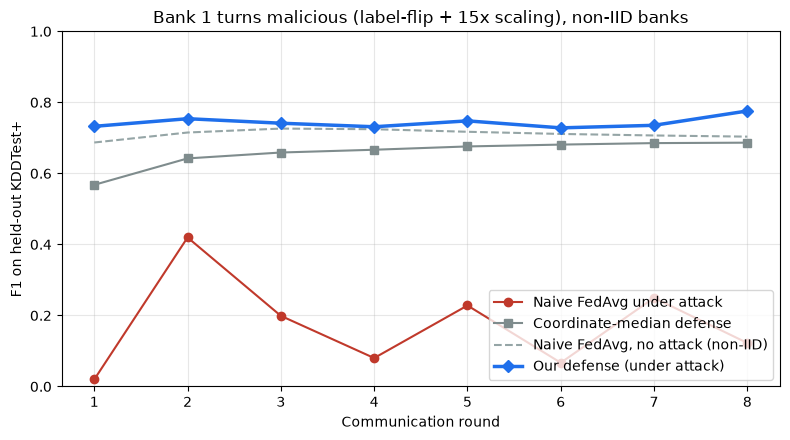

In [14]:
import matplotlib.pyplot as plt

rounds = range(1, 9)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rounds, [m["f1"] for m in attacked_history], "o-", color="#c0392b", label="Naive FedAvg under attack")
ax.plot(rounds, [m["f1"] for m in defended_history], "s-", color="#7f8c8d", label="Coordinate-median defense")
ax.plot(rounds, [m["f1"] for m in noniid_history], "--", color="#95a5a6", label="Naive FedAvg, no attack (non-IID)")
ax.plot(rounds, [m["f1"] for m in my_defense_history], "D-", color="#1f6feb", lw=2.5, label="Our defense (under attack)")
ax.set_xlabel("Communication round"); ax.set_ylabel("F1 on held-out KDDTest+")
ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(loc="lower right")
ax.set_title("Bank 1 turns malicious (label-flip + 15x scaling), non-IID banks")
plt.tight_layout(); plt.savefig("f1_over_rounds.png", dpi=160); plt.show()

---
## 8. Submission (rubric-graded, no Kaggle leaderboard)

Run this to export your final model. Pick whichever result (intermediate aggregation or
advanced defense) you want judged — set `TRACK` and `FINAL_MODEL` accordingly.

**Input contract:** your exported model's `forward(x)` must accept the standard 41-column
preprocessed feature tensor exactly as produced in Section 1 (`FEATURE_COLS`, same order,
same scaling). If you did feature engineering, build it as extra layers *inside* your model
rather than as a separate preprocessing step.


In [15]:

TEAM_NAME = "Athena Techne"
TRACK = "advanced"  # "intermediate" or "advanced"
FINAL_MODEL = my_defense_model  # <- point this at whichever model you want submitted

final_metrics = evaluate(FINAL_MODEL)

FINAL_MODEL.eval()
scripted = torch.jit.script(FINAL_MODEL)
scripted.save("model_scripted.pt")

submission = {
    "team_name": TEAM_NAME,
    "track": TRACK,
    "self_reported_metrics": final_metrics,
    "model_file": "model_scripted.pt",
    "n_input_features": N_FEATURES,
}
with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2)

print(json.dumps(submission, indent=2))
print("\\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).")


/home/cyril/try/.venv/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


{
  "team_name": "Athena Techne",
  "track": "advanced",
  "self_reported_metrics": {
    "precision": 0.9676,
    "recall": 0.6475,
    "f1": 0.7758
  },
  "model_file": "model_scripted.pt",
  "n_input_features": 41
}
\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).


### What to hand in
1. Your Kaggle Writeup — include the before/after F1 comparison for whichever track(s) you
   attempted, this is your primary evidence for the Automated Detection Score.
2. Your GitHub repo (Project Link) containing `model_scripted.pt`, `submission.json`, and
   this notebook, fully run.
3. Cover image, video (≤3 min), all per the Submission Requirements.
4. Be ready to demo live on Day 7.
